Saved PSD → ./Al2O3_Al_athermal/Er_noise.npy  [2×16385] (DC=0 added)
Saved PSD → ./Al2O3_Al_athermal/Johnson_noise.npy  [2×16385] (DC=0 added)
Saved PSD → ./Al2O3_Al_athermal/SQUID_noise.npy  [2×16385] (DC=0 added)
Saved PSD → ./Al2O3_Al_athermal/TD_noise.npy  [2×16385] (DC=0 added)
Saved PSD → ./Al2O3_Al_athermal/total_noise.npy  [2×16385] (DC=0 added)
Saved signal → ./Al2O3_Al_athermal/signal.npy  [2×16385] (DC=0 added)


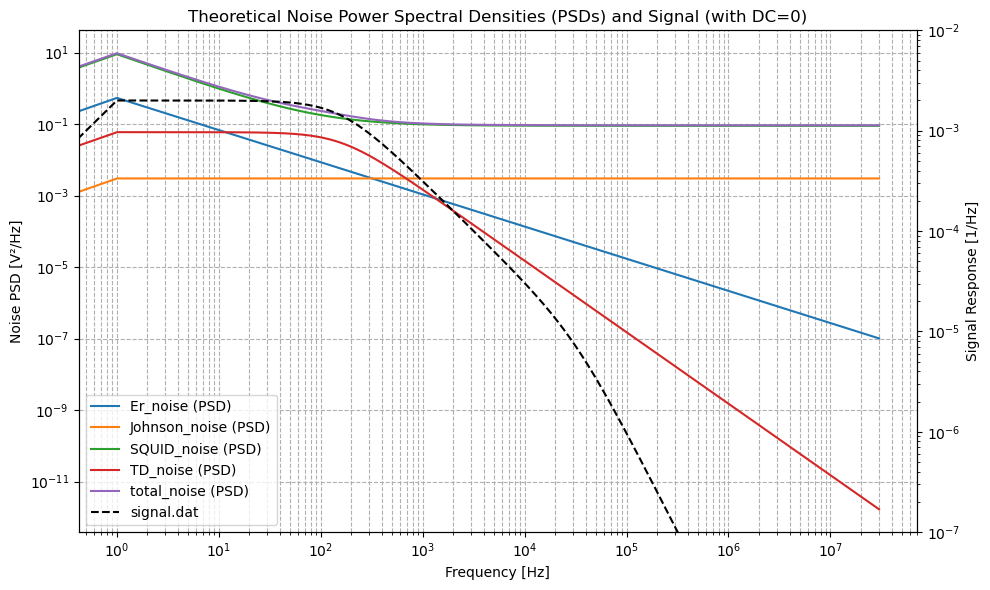

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Base path and list of files (assumed to be amplitude spectral density: units /√Hz)
base_path = "./Al2O3_Al_athermal/"
file_names = [
    "Er_noise.dat",
    "Johnson_noise.dat",
    "SQUID_noise.dat",
    "TD_noise.dat",
    "total_noise.dat",
]

signal_file = "signal.dat"

def load_two_cols(path):
    """
    Load at least two columns [freq, value] from a text file.
    Returns frequency and value as 1D float arrays, sorted by freq, with finite & positive freq only.
    """
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"{path} should have at least two columns [freq, value].")
    freq = np.asarray(arr[:, 0], dtype=float)
    val = np.asarray(arr[:, 1], dtype=float)

    # Keep only finite rows and positive frequencies
    finite = np.isfinite(freq) & np.isfinite(val) & (freq > 0)
    freq, val = freq[finite], val[finite]

    # Sort by frequency
    if freq.size:
        order = np.argsort(freq)
        freq, val = freq[order], val[order]

    return freq, val

def prepend_dc(freq, values):
    """
    Prepend a DC (0 Hz) frequency bin with value 0.
    """
    freq = np.insert(freq, 0, 0.0)
    values = np.insert(values, 0, 0.0)
    return freq, values

def save_npy_2xN(out_path, freq, values):
    """Save a 2×N float64 array [freq; values] to .npy."""
    arr_2xN = np.vstack((freq, values))
    np.save(out_path, arr_2xN)

# Prepare to load and plot noise PSD data
fig, ax1 = plt.subplots(figsize=(10, 6))
data_dict = {}

# Plot noise PSDs on the left Y-axis (PSD = ASD^2) and save in 2×N format
for fname in file_names:
    full_path = os.path.join(base_path, fname)
    try:
        freq, asd = load_two_cols(full_path)
        psd = np.square(asd)  # convert ASD (per √Hz) → PSD (per Hz)

        # Add true DC (0 Hz, value = 0)
        freq_dc, psd_dc = prepend_dc(freq, psd)
        data_dict[fname] = (freq_dc, psd_dc)

        # Save PSD as .npy with DC component
        out_name = os.path.splitext(fname)[0] + ".npy"
        out_path = os.path.join(base_path, out_name)
        save_npy_2xN(out_path, freq_dc, psd_dc)
        print(f"Saved PSD → {out_path}  [2×{psd_dc.size}] (DC=0 added)")

        ax1.loglog(freq_dc, psd_dc, label=f"{os.path.splitext(fname)[0]} (PSD)")
    except Exception as e:
        print(f"Could not read {fname}: {e}")

# Format left axis (noise PSD)
ax1.set_xlabel("Frequency [Hz]")
ax1.set_ylabel("Noise PSD [V²/Hz]")  # e.g., (μΦ₀)²/Hz
ax1.grid(True, which='both', linestyle='--')

# Plot signal data on a second Y-axis (also with DC=0)
ax2 = ax1.twinx()
try:
    freq_sig, values_sig = load_two_cols(os.path.join(base_path, signal_file))
    freq_sig_dc, values_sig_dc = prepend_dc(freq_sig, values_sig)
    data_dict[signal_file] = (freq_sig_dc, values_sig_dc)
    ax2.loglog(freq_sig_dc, values_sig_dc, label="signal.dat", color='black', linestyle='--')
    ax2.set_ylabel("Signal Response [1/Hz]")
    ax2.set_ylim(1e-7, 1e-2)

    # Also save signal with DC=0
    save_npy_2xN(os.path.join(base_path, "signal.npy"), freq_sig_dc, values_sig_dc)
    print(f"Saved signal → {os.path.join(base_path, 'signal.npy')}  [2×{values_sig_dc.size}] (DC=0 added)")
except Exception as e:
    print(f"Could not read {signal_file}: {e}")

# Combined legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title("Theoretical Noise Power Spectral Densities (PSDs) and Signal (with DC=0)")
plt.tight_layout()
plt.show()


In [3]:
import numpy as np
import os

base_path = "./Al2O3_Al_athermal/"
file_names = [
    "Er_noise.dat",
    "Johnson_noise.dat",
    "SQUID_noise.dat",
    "TD_noise.dat",
    "total_noise.dat",
]
signal_file = "signal.dat"

def load_two_cols(path):
    arr = np.loadtxt(path)
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"{path} should have at least two columns [freq, value].")
    freq = np.asarray(arr[:, 0], dtype=float)
    val  = np.asarray(arr[:, 1], dtype=float)
    finite = np.isfinite(freq) & np.isfinite(val) & (freq > 0)
    freq, val = freq[finite], val[finite]
    order = np.argsort(freq)
    return freq[order], val[order]

def to_2xN(freq, values):
    freq = np.asarray(freq, dtype=np.float64)
    values = np.asarray(values, dtype=np.float64)
    return np.vstack((freq, values))

print("=== Noise PSD dimensions check ===")

for fname in file_names:
    full_path = os.path.join(base_path, fname)
    try:
        freq, asd = load_two_cols(full_path)
        psd = np.square(asd)
        arr_2xN = to_2xN(freq, psd)
        print(f"{fname:<20} → shape {arr_2xN.shape}, dtype {arr_2xN.dtype}")
    except Exception as e:
        print(f"{fname:<20} → ERROR: {e}")

# Optionally include signal file for comparison
try:
    freq_sig, values_sig = load_two_cols(os.path.join(base_path, signal_file))
    sig_arr = to_2xN(freq_sig, values_sig)
    print(f"{signal_file:<20} → shape {sig_arr.shape}, dtype {sig_arr.dtype}")
except Exception as e:
    print(f"{signal_file:<20} → ERROR: {e}")

# Example comparison with reference npy file (noise_psd_xray.npy)
try:
    ref = np.load("noise_psd_xray.npy", allow_pickle=False)
    print(f"{'noise_psd_xray.npy':<20} → shape {ref.shape}, dtype {ref.dtype}")
except Exception as e:
    print(f"noise_psd_xray.npy       → ERROR: {e}")


=== Noise PSD dimensions check ===
Er_noise.dat         → shape (2, 16384), dtype float64
Johnson_noise.dat    → shape (2, 16384), dtype float64
SQUID_noise.dat      → shape (2, 16384), dtype float64
TD_noise.dat         → shape (2, 16384), dtype float64
total_noise.dat      → shape (2, 16384), dtype float64
signal.dat           → shape (2, 16384), dtype float64
noise_psd_xray.npy   → shape (2, 16385), dtype float64


In [5]:
import numpy as np
import os

base_path = "./Al2O3_Al_athermal/"
ref_path = "noise_psd_xray.npy"

# Load one of the .dat noise files
fname = "total_noise.dat"
freq_dat, asd_dat = np.loadtxt(os.path.join(base_path, fname), unpack=True)

# Load reference npy
freq_npy, psd_npy = np.load(ref_path, allow_pickle=False)

print(f"{fname:<20} → shape {freq_dat.shape}")
print(f"noise_psd_xray.npy       → shape {freq_npy.shape}")
print()

# Compare first few and last few frequencies
print("First 5 frequencies (.dat):", freq_dat[:5])
print("First 5 frequencies (.npy):", freq_npy[:5])
print("Last 5 frequencies (.dat): ", freq_dat[-5:])
print("Last 5 frequencies (.npy): ", freq_npy[-5:])

# Detect any missing frequency (e.g. 0 Hz)
if freq_npy[0] == 0 and freq_dat[0] > 0:
    print("\n✅ The .npy file includes the DC (0 Hz) frequency bin — hence 16385 points instead of 16384.")
elif len(freq_npy) == len(freq_dat) + 1:
    print("\n⚠️ The .npy file likely includes one extra bin (possibly DC or Nyquist).")
else:
    print("\nℹ️ Different number of points — possibly due to resampling or bin trimming.")


total_noise.dat      → shape (16384,)
noise_psd_xray.npy       → shape (16385,)

First 5 frequencies (.dat): [1.         1.00105144 1.00210399 1.00315764 1.0042124 ]
First 5 frequencies (.npy): [  0.         119.20929292 238.41858584 357.62787877 476.83717169]
Last 5 frequencies (.dat):  [29874158.0450101  29905568.95893975 29937012.89959145 29968489.90169078
 30000000.00000001]
Last 5 frequencies (.npy):  [1952648.21806646 1952767.42735938 1952886.6366523  1953005.84594523
 1953125.05523815]

✅ The .npy file includes the DC (0 Hz) frequency bin — hence 16385 points instead of 16384.


In [6]:

# Load .dat file
freq_dat, asd_dat = np.loadtxt(os.path.join(base_path, fname), unpack=True)
freq_dat = np.asarray(freq_dat, dtype=float)

# Load .npy file
freq_npy, psd_npy = np.load(ref_path, allow_pickle=False)
freq_npy = np.asarray(freq_npy, dtype=float)

print("=== Frequency Axis Comparison ===")
print(f"{fname:<22} → len = {len(freq_dat)}")
print(f"noise_psd_xray.npy         → len = {len(freq_npy)}")

print("\nFirst few frequencies:")
print(f"  {fname:<22} {freq_dat[:5]}")
print(f"  noise_psd_xray.npy        {freq_npy[:5]}")

print("\nLast few frequencies:")
print(f"  {fname:<22} {freq_dat[-5:]}")
print(f"  noise_psd_xray.npy        {freq_npy[-5:]}")

# Check whether DC bin (0 Hz) exists
if np.isclose(freq_npy[0], 0.0, atol=1e-12):
    print("\n✅ The .npy file includes a DC (0 Hz) frequency bin.")
else:
    print("\n❌ The .npy file does NOT include a 0 Hz frequency bin.")

if np.isclose(freq_dat[0], 0.0, atol=1e-12):
    print("⚠️  The .dat file ALSO includes a DC (0 Hz) frequency bin.")
else:
    print("ℹ️  The .dat file starts from a nonzero frequency.")

=== Frequency Axis Comparison ===
total_noise.dat        → len = 16384
noise_psd_xray.npy         → len = 16385

First few frequencies:
  total_noise.dat        [1.         1.00105144 1.00210399 1.00315764 1.0042124 ]
  noise_psd_xray.npy        [  0.         119.20929292 238.41858584 357.62787877 476.83717169]

Last few frequencies:
  total_noise.dat        [29874158.0450101  29905568.95893975 29937012.89959145 29968489.90169078
 30000000.00000001]
  noise_psd_xray.npy        [1952648.21806646 1952767.42735938 1952886.6366523  1953005.84594523
 1953125.05523815]

✅ The .npy file includes a DC (0 Hz) frequency bin.
ℹ️  The .dat file starts from a nonzero frequency.


In [11]:
import numpy as np

ref_path = "noise_psd_xray.npy"

# Load the file
arr = np.load(ref_path, allow_pickle=False)

# Ensure the shape matches expectations (2×N)
print(f"File: {ref_path}")
print(f"Shape: {arr.shape}")

# Extract frequency and PSD arrays
freq = arr[0]
psd = arr[1]

# Check if first frequency is 0 (DC) and what its PSD value is
print("\nFirst few frequencies:", freq[:5])
print("First few PSD values:", psd[:5])

if np.isclose(freq[0], 0.0, atol=1e-12):
    print("\n✅ The file includes a DC (0 Hz) bin.")
    if np.isclose(psd[0], 0.0, atol=1e-20):
        print("✅ The DC component PSD value is 0.")
    else:
        print(f"⚠️  The DC component PSD value is nonzero: {psd[0]:.3e}")
else:
    print("❌ The file does not start at DC (0 Hz).")


File: noise_psd_xray.npy
Shape: (2, 16385)

First few frequencies: [  0.         119.20929292 238.41858584 357.62787877 476.83717169]
First few PSD values: [0.00137406 0.00137406 0.00137406 0.00100122 0.00062839]

✅ The file includes a DC (0 Hz) bin.
⚠️  The DC component PSD value is nonzero: 1.374e-03
